# 01 — Lens and concept vectors

This phase treats both direction constructions as first-class: (1) the official published Qwen2.5-7B Jacobian lens (485 fitted WikiText prompts) and (2) a non-J-Lens mean-difference direction. The MD bank is frozen before model scoring: 40 concept-level labels, four independently authored training facts and two held-out facts each. Silent prompts ask the model to hold the answer in mind; they never reuse a behavioral prompt or ask for an output. Matched-template baselines exclude each task-paired foil. The strict 7B spider gate failed in notebook 00, so these artifacts remain diagnostic until a scale passes that gate.

In [1]:
import os
from pathlib import Path

ROOT = Path('/home/jovyan/j-space-thoughts')
os.chdir(ROOT)
os.environ['PIP_USER'] = 'false'
os.environ['PYTHONNOUSERSITE'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
print('Notebook 00 checkpoint present:', (ROOT / 'results/metrics.json').exists())

Notebook 00 checkpoint present: True


## Known-answer validation

Before any activation is collected, a fail-closed audit checks source-pair identity, NFKC/casefold and token-ID leakage, train/held-out fact separation, six-token overlap with every behavioral prompt, hashes, truncation, and the common final anchor. At fixed layer 18, validation reports held-out sign, train-calibrated 40-way retrieval with bootstrap CIs and a label-permutation test, separate explicit-answer controls, silent-output contamination, and leave-one-cue-out stability. Direction signs and the layer are never selected using held-out scores or J-Lens alignment. Cosines with raw $W_UJ$ and RMS-gain-folded sensitivity are diagnostic only.

In [2]:
from src.concept_phase import run_concept_vector_phase

summary = run_concept_vector_phase()

MD CUE AUDIT PASS: 40 concepts, 160 train + 80 held-out cues


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Capturing silent MD cues in shared batches: layers=[11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25], fixed validation layer=18


Running separate explicit known-answer probes and silent contamination probes


NB01 FAIL: N=40 concepts; retrieval top1=0.062 95% CI [0.013, 0.113]; explicit top1=0.525; silent top10=0.079; LOO median cosine=0.905
Failed preregistered MD validation criteria: ['retrieval_top1_ci_above_chance', 'explicit_top5_at_least_0.80']


In [3]:
import pandas as pd

display(pd.DataFrame([
    {'control': 'held-out 40-way retrieval top-1', **{k: summary['heldout_retrieval']['top1_at_fixed_layer'][k] for k in ['n','estimate','ci_low','ci_high']}},
    {'control': 'held-out macro OvR AUROC', **{k: summary['heldout_retrieval']['macro_ovr_auroc_at_fixed_layer'][k] for k in ['n','estimate','ci_low','ci_high']}},
    {'control': 'explicit held-out answer top-1', **{k: summary['explicit_known_answer']['top1'][k] for k in ['n','estimate','ci_low','ci_high']}},
    {'control': 'explicit held-out answer top-5', **{k: summary['explicit_known_answer']['top5'][k] for k in ['n','estimate','ci_low','ci_high']}},
    {'control': 'silent target-token top-10', **{k: summary['silent_output_contamination']['top10'][k] for k in ['n','estimate','ci_low','ci_high']}},
]))
display(pd.DataFrame([
    {'alignment': name, **{k: values[k] for k in ['n','estimate','ci_low','ci_high']}}
    for name, values in summary['cosine_alignment'].items() if name != 'per_concept_layer'
]))
display(pd.Series(summary['criteria'], name='passed').to_frame())
print('Cue leakage audit:', summary['cue_audit']['status'])
print('Fixed validation layer:', summary['fixed_validation_layer'])
print('LOO median cosine:', summary['leave_one_slot_out_stability']['median_cosine_at_fixed_layer'])
print('Maximum unit-norm error:', summary['max_unit_norm_error'])
print('Saved direction artifact:', summary['artifact'])

,control,n,estimate,ci_low,ci_high
0,held-out 40-way retrieval top-1,80,0.062500,0.012500,0.112500
1,held-out macro OvR AUROC,40,0.770192,0.731571,0.808173
2,explicit held-out answer top-1,80,0.525000,0.425000,0.637500
3,explicit held-out answer top-5,80,0.762500,0.662500,0.850000
4,silent target-token top-10,240,0.079167,0.045833,0.116667


,alignment,n,estimate,ci_low,ci_high
0,raw_WU_J,40,0.043101,0.038304,0.047924
1,rms_gain_folded,40,0.051002,0.046224,0.055623


,passed
heldout_sign_fraction_at_least_0.80,True
heldout_sign_mean_ci_excludes_zero,True
retrieval_top1_ci_above_chance,False
retrieval_auroc_ci_above_half,True
retrieval_permutation_p_below_0.01,True
explicit_top1_at_least_0.50,True
explicit_top5_at_least_0.80,False
silent_top1_at_most_0.10,True
silent_top10_at_most_0.25,True
loo_median_cosine_at_least_0.70,True


Cue leakage audit: PASS
Fixed validation layer: 18
LOO median cosine: 0.9050613378723467
Maximum unit-norm error: 2.384185791015625e-07
Saved direction artifact: data/directions/qwen2.5-7b_concept_vectors.pt


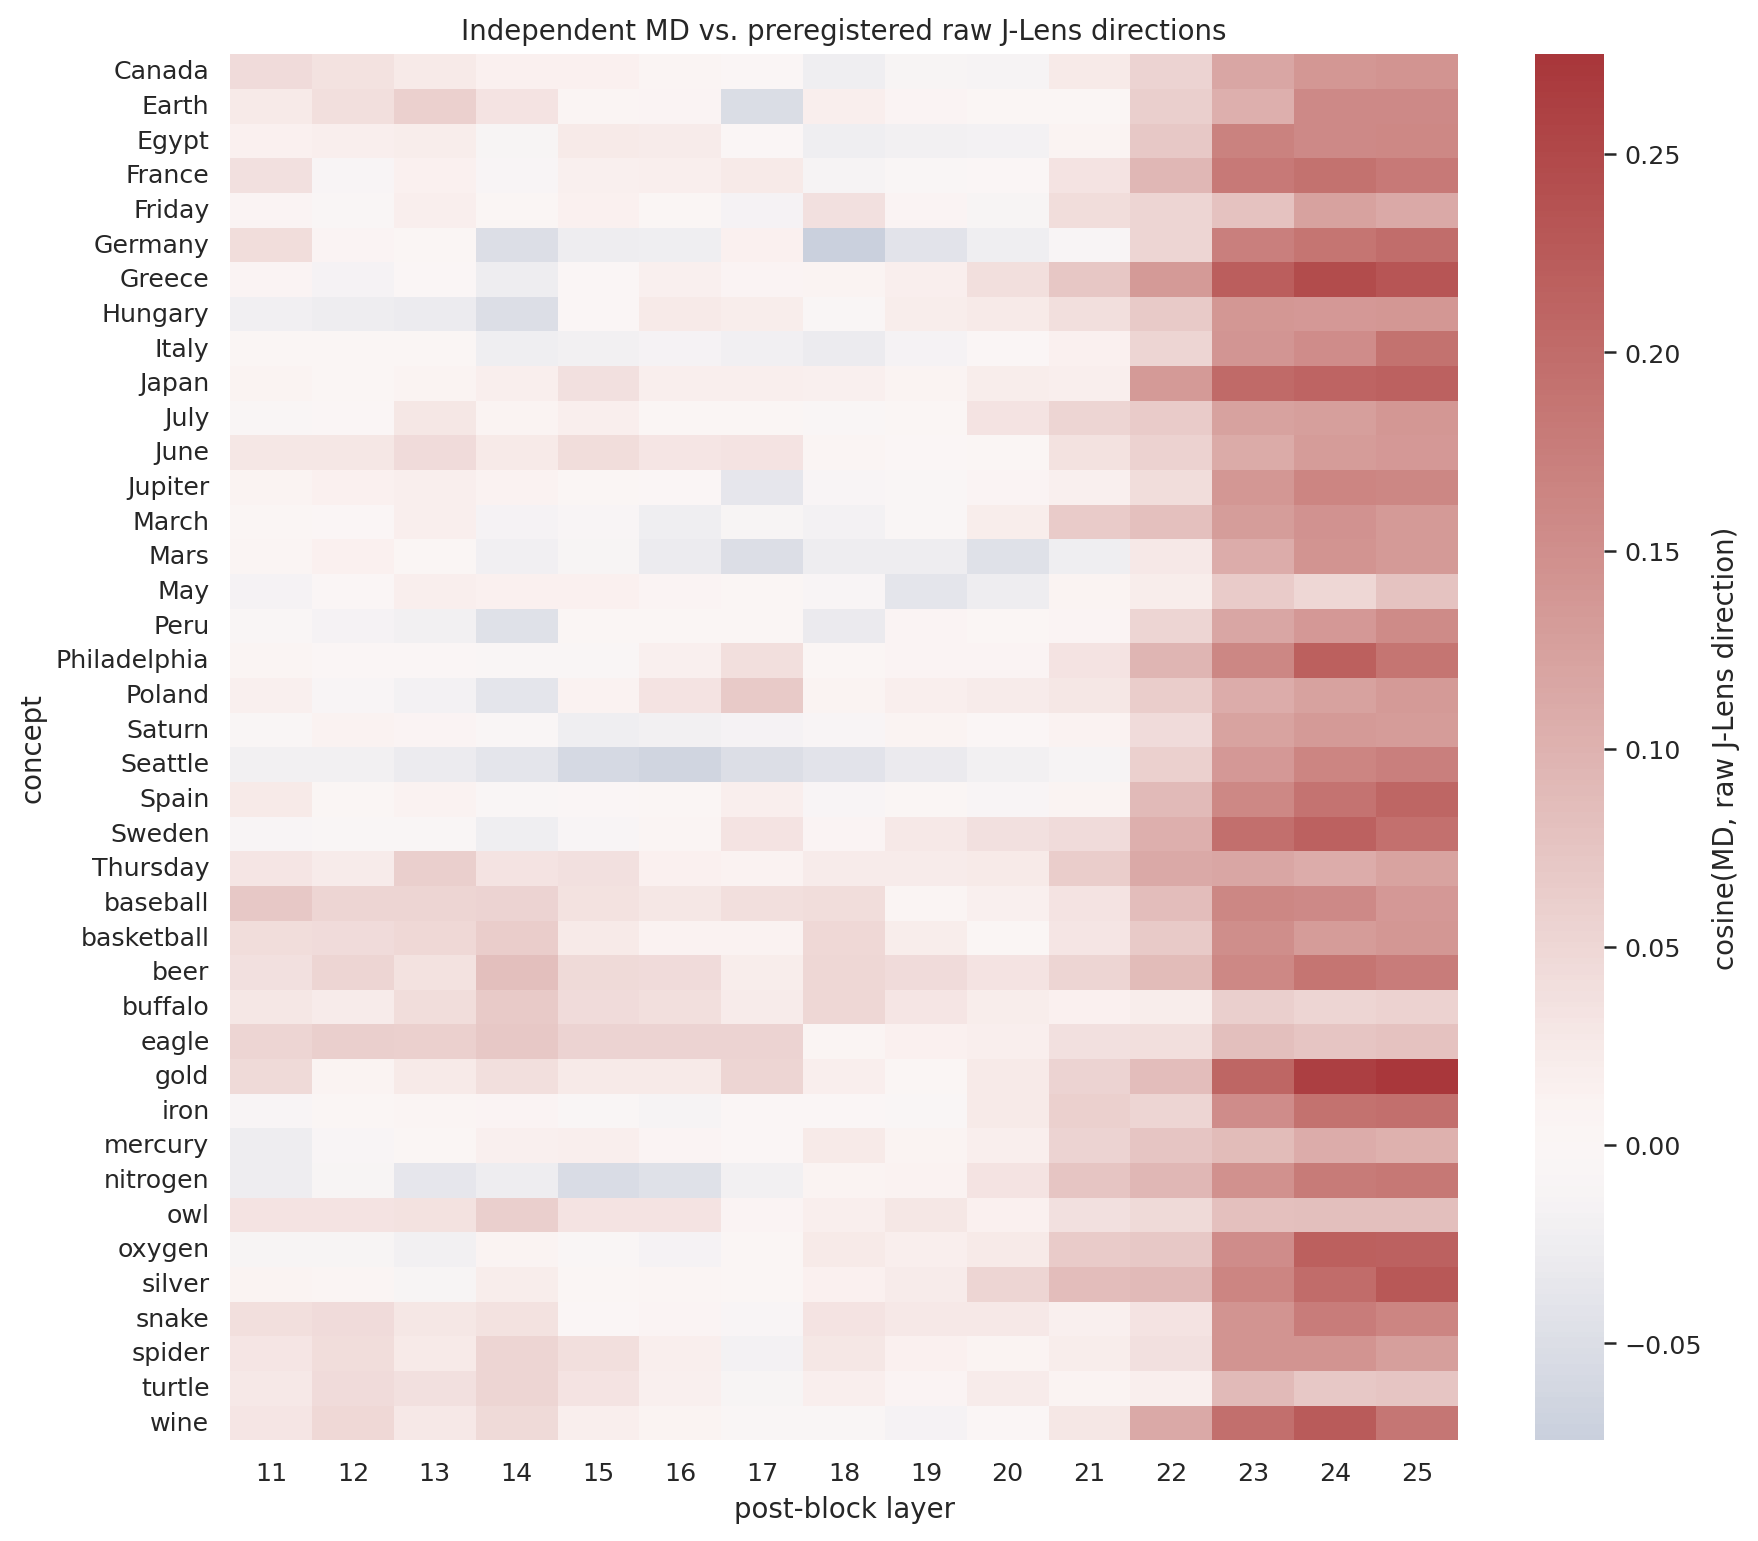

In [4]:
from IPython.display import Image, display

display(Image(filename=str(ROOT / summary['figure'])))

In [5]:
print(f"PHASE 01 {summary['status']}")
print(f"N concepts: {summary['n_concepts']}")
if summary['status'] != 'PASS':
    print('Mean-difference directions failed at least one frozen validation criterion; downstream MD results are retained but cannot support a headline claim.')
else:
    print('Mean-difference directions passed the preregistered known-answer control.')

PHASE 01 FAIL
N concepts: 40
Mean-difference directions failed at least one frozen validation criterion; downstream MD results are retained but cannot support a headline claim.
